In [1]:
import pickle
import random

import torch

# Fix the kernel dying?
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from eval_knn_proto import *

In [16]:
tensor_dict_path = "C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\meta-learning-sup-que-ds\\maml_tensor_dict.pkl"

with open(tensor_dict_path, "rb") as f:
    tensor_dict = pickle.load(f)

In [10]:
config = {
    "tensor_dict": tensor_dict,
    "shots": [1, 3, 5],
    "n_way": 10,

    "knn_metric": "euclidean",
    "seed": 42,

    # TODO: Idk if it takes this in...
    #"train_PIDs":   ["P102","P114"],        
            #["P102","P114","P119","P005","P107","P126","P132","P112",
            #"P103","P125","P127","P010","P128","P111","P118",
            #"P124","P110","P116","P108","P104","P122","P131","P106","P115"],

    # I dont think these are currently accepted/ Or they are but in a weird way.
    #"train_reps":  [1],   # These are REPITIONS NOT CLASSES! So we should do a split here
    #"val_reps":[2, 3, 4, 5, 6, 7, 8, 9, 10],

    "eval_PIDs":           ["P011","P006","P105","P109"],
    "maml_reps":           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "use_imu":             False,
    "aug_support":         False,
    "aug_n_copies":        4,
    "aug_noise_std":       0.05,
    "aug_max_shift":       4,
    "aug_ch_drop":         0.10,
    "emg_pca_dims":        8,  
    "imu_pca_dims":        18,  
    "shared_pca":          False, 

    # I think these two define the same thing but are just different names for it. Not sure if random_split is called at all...
    "use_fixed_rep_split": True,
    "random_split": False,  # Random-shuffle split instead of fixed-rep split --> I think this is for MAML... so I wont be using it all all here right?
    # ^ Participant IDs to evaluate (default: 1-24 --> Does this default actually exist??) --> So default to intra-subject ig? Is it doing strictly within user? I am not sure lol

    "device":              "cuda" if torch.cuda.is_available() else "cpu",
}

In [11]:
#plot_pca_variance(my_emg_tensor, my_imu_tensor)

In [12]:
import torch
import matplotlib.pyplot as plt
from typing import Optional, Union, Dict

def ensure_channel_first(x: torch.Tensor) -> torch.Tensor:
    """Helper from eval_knn_proto.py to ensure (N, C, T) shape."""
    if x is None or x.dim() != 3:
        return x
    # If the last dimension matches known channel counts, swap it
    if x.shape[-1] in [16, 72]:
        return x.permute(0, 2, 1)
    return x

def plot_pca_variance(
    data: Union[torch.Tensor, Dict], 
    pid: Optional[Union[str, int]] = None,
    imu_data: Optional[torch.Tensor] = None, 
    save_path: str = "pca_variance_analysis.png"
):
    """
    Analyzes PCA variance. 
    Accepts either:
      1. A tensor_dict + pid (automatically extracts and cats all gestures)
      2. Raw EMG and IMU tensors (N, C, T)
    """
    emg_tensor = None
    imu_tensor = imu_data

    # --- Data Extraction Logic ---
    if isinstance(data, dict):
        # If it's the full tensor_dict, we need to pick a participant
        target_pid = pid if pid is not None else list(data.keys())[0]
        user_data = data[target_pid]
        
        emg_list, imu_list = [], []
        # Flatten across all gestures for this user to get a global variance view
        for gid in user_data.keys():
            if 'emg' in user_data[gid]:
                emg_list.append(ensure_channel_first(user_data[gid]['emg']))
            if 'imu' in user_data[gid] and user_data[gid]['imu'] is not None:
                imu_list.append(ensure_channel_first(user_data[gid]['imu']))
        
        emg_tensor = torch.cat(emg_list, dim=0) if emg_list else None
        imu_tensor = torch.cat(imu_list, dim=0) if imu_list else None
        print(f"Aggregated {len(emg_list)} gestures for PID {target_pid}")
    else:
        emg_tensor = ensure_channel_first(data)
        imu_tensor = ensure_channel_first(imu_data)

    # --- PCA Calculation Logic ---
    def get_cum_variance(x):
        N, C, T = x.shape
        # (N, C, T) -> (N*T, C)
        x_flat = x.permute(0, 2, 1).reshape(-1, C)
        x_centered = x_flat - torch.mean(x_flat, dim=0)
        cov = torch.matmul(x_centered.T, x_centered) / (x_centered.shape[0] - 1)
        eigenvalues, _ = torch.linalg.eigh(cov)
        eigenvalues = torch.flip(eigenvalues, dims=[0])
        var_ratio = eigenvalues / torch.sum(eigenvalues)
        return torch.cumsum(var_ratio, dim=0).cpu().numpy()

    plots = []
    if emg_tensor is not None: plots.append(('EMG', emg_tensor))
    if imu_tensor is not None: plots.append(('IMU', imu_tensor))
    if emg_tensor is not None and imu_tensor is not None:
        # Note: In shared PCA, variance is dominated by the modality with larger scale
        shared = torch.cat([emg_tensor, imu_tensor], dim=1)
        plots.append(('Shared (EMG+IMU)', shared))

    # --- Plotting ---
    fig, axes = plt.subplots(1, len(plots), figsize=(6 * len(plots), 5))
    if len(plots) == 1: axes = [axes]

    for i, (label, tensor) in enumerate(plots):
        cum_var = get_cum_variance(tensor)
        comps = range(1, len(cum_var) + 1)
        
        axes[i].plot(comps, cum_var, 'o-', markersize=4)
        axes[i].set_title(f'{label} Variance')
        axes[i].set_xlabel('Number of Components')
        axes[i].set_ylabel('Cum. Explained Variance')
        axes[i].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95%')
        axes[i].grid(True, alpha=0.3)
        
        # Mark the 95% threshold
        n_95 = (cum_var >= 0.95).argmax() + 1
        axes[i].annotate(f'{n_95} PCs', xy=(n_95, 0.95), xytext=(n_95, 0.7),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))
        axes[i].legend(loc='lower right')

    plt.tight_layout()
    #plt.savefig(save_path)
    print(f"Plot saved to {save_path}")

Aggregated 10 gestures for PID P124
Plot saved to pca_variance_analysis.png


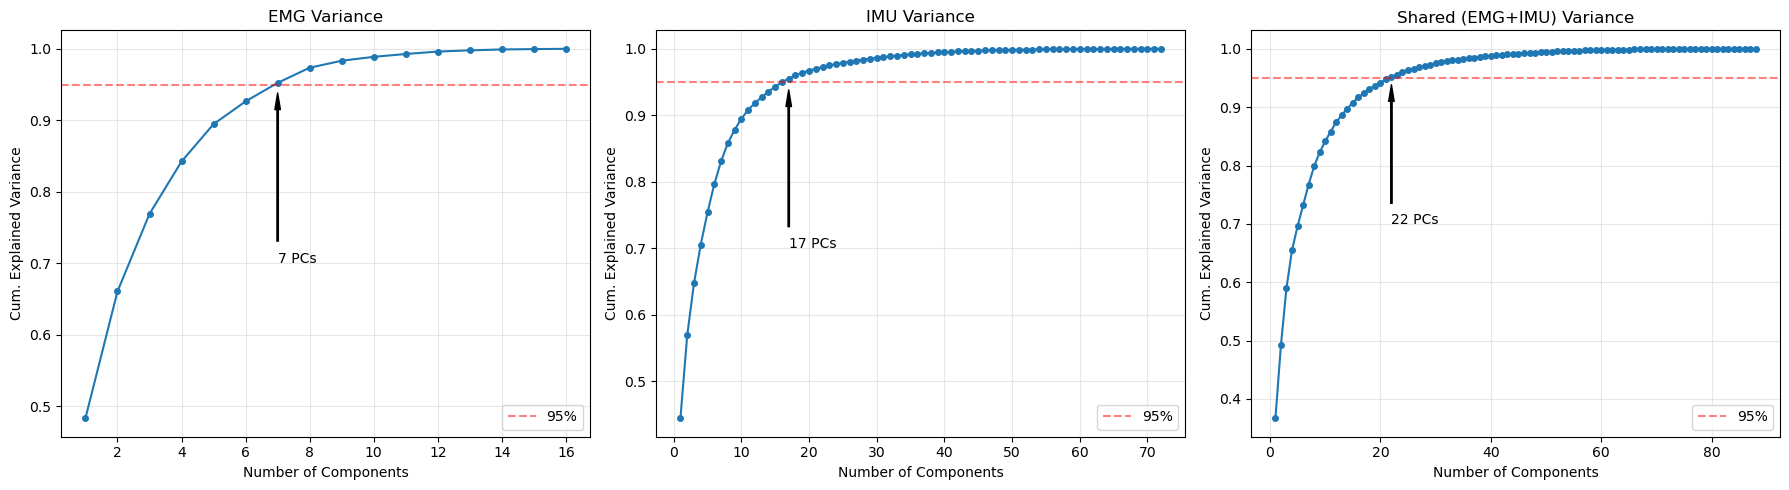

In [13]:
# This will automatically separate EMG/IMU and create the 3 plots
plot_pca_variance(tensor_dict, pid="P124")  # Randomly chose P124

In [14]:
# EMG: 7-8 PCs
# IMU: 16-18 PCs
# EMG+IMU concat: 20-24 PCs --> $B used 50...

In [17]:
# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=euclidean
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)
  aug        : False
  EMG PCA dims   : 8
  encoder    : None
  users      : 4
  PID P011 | knn=10.0%  knn_pca=10.0%  proto=11.1%  proto_pca=11.1%  [sup=10, qry=90]
  PID P006 | knn=10.0%  knn_pca=10.0%  proto=8.9%  proto_pca=8.9%  [sup=10, qry=90]
  PID P105 | knn=10.0%  knn_pca=10.0%  proto=11.1%  proto_pca=11.1%  [sup=10, qry=90]
  PID P109 | knn=10.0%  knn_pca=10.0%  proto=11.1%  proto_pca=11.1%  [sup=10, qry=90]

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         10.00%    0.00%       4
  KNN (PCA)                         10.00%    0.00%       4
  ProtoNet (raw)                    10.56%    1.11%       4
  P